In [45]:
# Sanity check: confirm abTEM is installed and show the exact Python env VSCode is using.

import sys

try:
    import abtem
    print("abtem ok:", abtem.__version__)          # abTEM version (for reproducibility)
    print("python:", sys.version.split()[0])       # Python version
    print("executable:", sys.executable)           # Interpreter path (ensures correct conda env)
except Exception as e:
    print("abtem import failed:", repr(e))         # If this fails, install abTEM in this env

abtem ok: 1.0.6
python: 3.10.13
executable: /Users/kylexu/miniconda3/envs/matsci465/bin/python


In [46]:
import numpy as np
import abtem
from ase.build import bulk

# Force CPU execution (avoid GPU dependency / keep behavior consistent).
abtem.config.set({"device": "cpu"})

# Build a tiny fcc Ni supercell (fast) just to test abTEM output ordering/shape.
atoms = bulk("Ni", "fcc", a=3.52) * (4, 4, 2)
atoms = abtem.orthogonalize_cell(atoms)  # make cell orthogonal for cleaner scanning bounds

# Create multislice potential (sampling controls real-space grid resolution vs speed).
potential = abtem.Potential(atoms, sampling=0.2)

# Define probe (accelerating voltage + convergence semi-angle).
probe = abtem.Probe(energy=200e3, semiangle_cutoff=30)
probe.grid.match(potential)  # ensure probe grid matches potential grid

# Define scan extent over one unit-cell area (Lx, Ly) and a small scan grid.
Lx, Ly, _ = atoms.cell.lengths()
scan = abtem.GridScan(
    start=(0.0, 0.0),
    end=(Lx, Ly),
    gpts=(8, 6),            # scan grid requested in abTEM order; we infer output order from result
    endpoint=False,
    potential=potential,
)

# Pixelated detector produces a full diffraction pattern per scan position.
det = abtem.PixelatedDetector(max_angle=60)

# Run 4D-STEM simulation and convert to a NumPy array.
meas = probe.scan(potential, scan=scan, detectors=det).compute()
arr = np.asarray(meas.array)

# Print the raw ordering so we can transpose to required (scan_y, scan_x, diff_y, diff_x).
print("raw shape:", arr.shape)
print("raw dtype:", arr.dtype)

[########################################] | 100% Completed | 314.60 ms
raw shape: (8, 6, 69, 69)
raw dtype: float32


In [47]:
import numpy as np
import abtem
from ase.build import bulk
import matplotlib.pyplot as plt
from pathlib import Path

# Output folder to keep generated files organized.
OUTDIR = Path("abtem_outputs")
OUTDIR.mkdir(exist_ok=True)

# --- Simulation parameters (keep small for speed; increase later if needed) ---
energy_eV = 200e3          # accelerating voltage (200 kV)
semiangle_mrad = 30.0      # probe convergence semi-angle
max_angle_mrad = 60.0      # detector max scattering angle
sampling_A = 0.2           # potential sampling in Å (larger = faster, less accurate)

# Scan grid (required final ordering is (scan_y, scan_x, diff_y, diff_x)).
nx, ny = 32, 32            # reduce to 16x16 if too slow

# Crystal supercell (larger = more realistic, slower).
rep = (4, 4, 2)
a_A = 3.52                 # Ni fcc lattice parameter (Å)

abtem.config.set({"device": "cpu"})  # run on CPU for portability

# Build pure matrix structure (Ni only).
atoms = bulk("Ni", "fcc", a=a_A) * rep
atoms = abtem.orthogonalize_cell(atoms)

# Build potential + probe and match grids.
potential = abtem.Potential(atoms, sampling=sampling_A)
probe = abtem.Probe(energy=energy_eV, semiangle_cutoff=semiangle_mrad)
probe.grid.match(potential)

# Define scan over the unit-cell area and create a pixelated detector (full DP per position).
Lx, Ly, _ = atoms.cell.lengths()
scan = abtem.GridScan(
    start=(0.0, 0.0),
    end=(Lx, Ly),
    gpts=(nx, ny),          # abTEM returns (scan_x, scan_y, ky, kx)
    endpoint=False,
    potential=potential,
)
det = abtem.PixelatedDetector(max_angle=max_angle_mrad)

# Run the 4D-STEM simulation.
meas = probe.scan(potential, scan=scan, detectors=det).compute()
arr = np.asarray(meas.array, dtype=np.float32)          # raw: (nx, ny, ky, kx)

# Convert to pipeline-required ordering: (scan_y, scan_x, diff_y, diff_x).
data4d = np.transpose(arr, (1, 0, 2, 3)).astype(np.float32)  # (ny, nx, ky, kx)

print("matrix data4d shape:", data4d.shape, "dtype:", data4d.dtype)

# Save required matrix-only dataset.
np.save(OUTDIR / "abtem_matrix.npy", data4d)

# Save quick visual checks (mean DP + one example DP).
mean_dp = data4d.mean(axis=(0, 1))
ex_dp = data4d[ny // 2, nx // 2]

def _save_dp_png(dp, fname):
    plt.figure()
    plt.imshow(np.log1p(dp), origin="lower")  # log scale for visibility
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(fname, dpi=200)
    plt.close()

_save_dp_png(mean_dp, OUTDIR / "mean_dp_matrix.png")
_save_dp_png(ex_dp, OUTDIR / "example_dp_matrix.png")

print("saved:", OUTDIR / "abtem_matrix.npy", OUTDIR / "mean_dp_matrix.png", OUTDIR / "example_dp_matrix.png")

[########################################] | 100% Completed | 4.09 sms
matrix data4d shape: (32, 32, 69, 69) dtype: float32
saved: abtem_outputs/abtem_matrix.npy abtem_outputs/mean_dp_matrix.png abtem_outputs/example_dp_matrix.png


In [49]:
# Quick sanity check: load the saved matrix-only dataset and confirm basic stats.

import numpy as np
from pathlib import Path

OUTDIR = Path("abtem_outputs")

x = np.load(OUTDIR / "abtem_matrix.npy")   # (ny, nx, ky, kx)
print("shape:", x.shape)                   # should be (32, 32, 69, 69)
print("dtype:", x.dtype)                   # should be float32
print("min/max:", float(x.min()), float(x.max()))  # intensity range
print("mean:", float(x.mean()))            # average intensity

shape: (32, 32, 69, 69)
dtype: float32
min/max: 0.0 0.0021684346720576286
mean: 0.00020867474086117


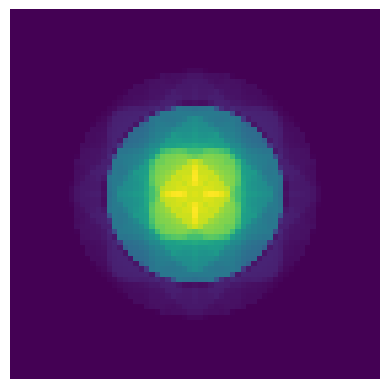

In [51]:
# Visualize one diffraction pattern from the 4D dataset (single scan position).

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTDIR = Path("abtem_outputs")

x = np.load(OUTDIR / "abtem_matrix.npy")          # (ny, nx, ky, kx)
dp = x[x.shape[0] // 2, x.shape[1] // 2]          # pick the center scan pixel

plt.figure()
plt.imshow(np.log1p(dp), origin="lower")          # log scale makes rings/spots visible
plt.axis("off")
plt.show()

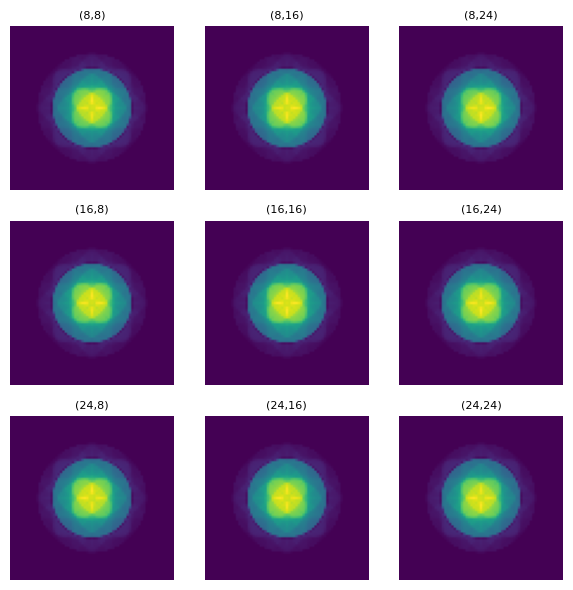

In [52]:
# Visualize multiple diffraction patterns across the scan (checks scan-to-scan variation).

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTDIR = Path("abtem_outputs")

x = np.load(OUTDIR / "abtem_matrix.npy")  # (ny, nx, ky, kx)
ny, nx, ky, kx = x.shape

# Sample 9 scan positions (3x3) spread across the field of view.
ys = [ny // 4, ny // 2, 3 * ny // 4]
xs = [nx // 4, nx // 2, 3 * nx // 4]

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, y in enumerate(ys):
    for j, x0 in enumerate(xs):
        dp = x[y, x0]  # diffraction pattern at scan position (y, x)
        axes[i, j].imshow(np.log1p(dp), origin="lower")
        axes[i, j].set_title(f"({y},{x0})", fontsize=8)
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Sanity check that they are not exactly the same

import numpy as np
from pathlib import Path

OUTDIR = Path("abtem_outputs")
x = np.load(OUTDIR / "abtem_matrix.npy")

# Compare a few positions to the center
ref = x[x.shape[0]//2, x.shape[1]//2]
for y, x0 in [(8,8),(8,16),(16,8),(24,24)]:
    diff = np.mean(np.abs(x[y, x0] - ref))
    print((y, x0), "mean|diff| =", float(diff))

(8, 8) mean|diff| = 7.591572739329422e-06
(8, 16) mean|diff| = 4.0579780034022406e-06
(16, 8) mean|diff| = 4.057784735778114e-06
(24, 24) mean|diff| = 7.591835128550883e-06


In [55]:
import json
import numpy as np
import abtem
from ase.build import bulk
import matplotlib.pyplot as plt
from pathlib import Path

# Output folder to keep generated files organized.
OUTDIR = Path("abtem_outputs")
OUTDIR.mkdir(exist_ok=True)

abtem.config.set({"device": "cpu"})  # run on CPU for portability

# --- Keep these consistent with the matrix-only run (so comparisons are fair) ---
energy_eV = 200e3
semiangle_mrad = 30.0
max_angle_mrad = 60.0
sampling_A = 0.2

nx, ny = 32, 32            # scan grid passed to abTEM as (scan_x, scan_y)
rep = (4, 4, 2)            # supercell size
a_A = 3.52                 # Ni fcc lattice parameter (Å)
# -------------------------------------------------------------------------------

def save_dp_png(dp, fname):
    """Save a diffraction pattern image (log scale) for quick visual checks."""
    plt.figure()
    plt.imshow(np.log1p(dp), origin="lower")
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(fname, dpi=200)
    plt.close()

# Build Ni matrix and define a W-rich cylindrical precipitate by Ni->W substitution.
atoms = bulk("Ni", "fcc", a=a_A) * rep
atoms = abtem.orthogonalize_cell(atoms)

Lx, Ly, Lz = atoms.cell.lengths()
cx, cy = Lx / 2.0, Ly / 2.0                      # precipitate center (Å)
r_precip_A = 0.18 * min(Lx, Ly)                  # precipitate radius (Å)

pos = atoms.get_positions()
in_cyl = (pos[:, 0] - cx) ** 2 + (pos[:, 1] - cy) ** 2 <= r_precip_A ** 2
symbols = np.array(atoms.get_chemical_symbols(), dtype=object)
symbols[in_cyl] = "W"                             # create second phase by composition change
atoms.set_chemical_symbols(symbols.tolist())

# Simulate 4D-STEM: potential + probe + scan + pixelated detector.
potential = abtem.Potential(atoms, sampling=sampling_A)
probe = abtem.Probe(energy=energy_eV, semiangle_cutoff=semiangle_mrad)
probe.grid.match(potential)

scan = abtem.GridScan(
    start=(0.0, 0.0),
    end=(Lx, Ly),
    gpts=(nx, ny),                                # abTEM raw output: (scan_x, scan_y, ky, kx)
    endpoint=False,
    potential=potential,
)
det = abtem.PixelatedDetector(max_angle=max_angle_mrad)

meas = probe.scan(potential, scan=scan, detectors=det).compute()
arr = np.asarray(meas.array, dtype=np.float32)    # raw: (nx, ny, ky, kx)

# Convert to pipeline-required ordering: (scan_y, scan_x, diff_y, diff_x).
data4d = np.transpose(arr, (1, 0, 2, 3)).astype(np.float32)  # (ny, nx, ky, kx)
print("precip data4d shape:", data4d.shape, "dtype:", data4d.dtype)

# Create ground-truth mask on the scan grid (must align with (ny,nx) scan positions).
xs = (np.arange(nx) + 0.5) * (Lx / nx)
ys = (np.arange(ny) + 0.5) * (Ly / ny)
X, Y = np.meshgrid(xs, ys)                        # (ny, nx)
gt_mask = (((X - cx) ** 2 + (Y - cy) ** 2) <= r_precip_A ** 2).astype(np.uint8)

print("mask shape:", gt_mask.shape, "dtype:", gt_mask.dtype, "precip fraction:", gt_mask.mean())

# Save required arrays.
np.save(OUTDIR / "abtem_precip.npy", data4d)
np.save(OUTDIR / "abtem_mask.npy", gt_mask)

# Save required visual checks (mean DP + one example DP inside/outside precipitate).
mean_dp_precip = data4d.mean(axis=(0, 1))
save_dp_png(mean_dp_precip, OUTDIR / "mean_dp_precip.png")

precip_idx = np.argwhere(gt_mask == 1)
matrix_idx = np.argwhere(gt_mask == 0)
if len(precip_idx) == 0 or len(matrix_idx) == 0:
    raise RuntimeError("Mask ended up all one class; adjust r_precip_A.")

py, px = precip_idx[len(precip_idx) // 2]         # one pixel inside precip
my, mx = matrix_idx[len(matrix_idx) // 2]         # one pixel in matrix

save_dp_png(data4d[py, px], OUTDIR / "example_dp_in_precip.png")
save_dp_png(data4d[my, mx], OUTDIR / "example_dp_in_matrix.png")

# Write metadata for reproducibility and grading checklist.
ky, kx = data4d.shape[2], data4d.shape[3]
meta = {
    "accelerating_voltage_kV": float(energy_eV / 1e3),
    "probe_semiangle_mrad": float(semiangle_mrad),
    "detector_max_angle_mrad": float(max_angle_mrad),
    "scan_size_A": [float(Lx), float(Ly)],
    "scan_grid_ny_nx": [int(ny), int(nx)],
    "diffraction_shape_ky_kx": [int(ky), int(kx)],
    "approx_diffraction_pixel_size_mrad": float((2 * max_angle_mrad) / max(ky - 1, 1)),
    "thickness_nm": float(Lz / 10.0),
    "number_of_slices": int(getattr(potential, "num_slices", 0) or 0),
    "structure_description": f"fcc Ni matrix (a={a_A} Å), replicated {rep}, with substitutional W-rich cylindrical region",
    "precipitate_composition": "W-rich (Ni -> W substitution inside cylinder)",
    "precipitate_radius_A": float(r_precip_A),
    "precipitate_center_xy_A": [float(cx), float(cy)],
    "output_ordering": "(scan_y, scan_x, diffraction_y, diffraction_x)",
    "dtype_data4d": "float32",
    "dtype_mask": "uint8",
}

with open(OUTDIR / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("saved:", OUTDIR / "abtem_precip.npy", OUTDIR / "abtem_mask.npy", OUTDIR / "meta.json",
      OUTDIR / "mean_dp_precip.png", OUTDIR / "example_dp_in_precip.png", OUTDIR / "example_dp_in_matrix.png")

[########################################] | 100% Completed | 4.06 sms
precip data4d shape: (32, 32, 69, 69) dtype: float32
mask shape: (32, 32) dtype: uint8 precip fraction: 0.109375
saved: abtem_outputs/abtem_precip.npy abtem_outputs/abtem_mask.npy abtem_outputs/meta.json abtem_outputs/mean_dp_precip.png abtem_outputs/example_dp_in_precip.png abtem_outputs/example_dp_in_matrix.png


mean(dp_in)= 0.00020545566803775728 mean(dp_out)= 0.00020851621229667217
L1 diff (normalized)= 0.0952662317799136


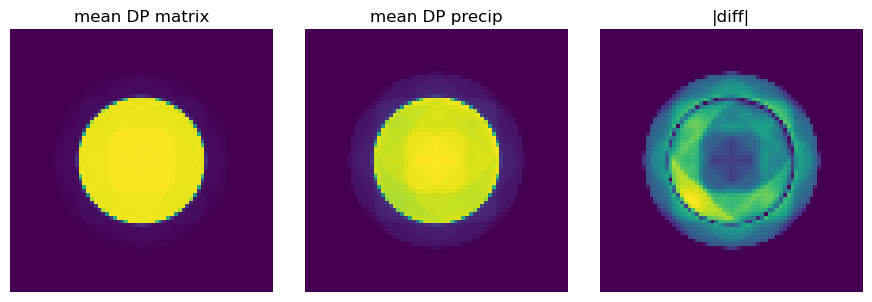

In [57]:
# Sanity check: confirm the precipitate region has a measurably different mean diffraction pattern vs matrix.

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTDIR = Path("abtem_outputs")

data = np.load(OUTDIR / "abtem_precip.npy")          # (ny, nx, ky, kx)
mask = np.load(OUTDIR / "abtem_mask.npy").astype(bool)  # (ny, nx), True = precip

# Average diffraction patterns inside vs outside the precipitate mask.
dp_in  = data[mask].mean(axis=0)                     # (ky, kx)
dp_out = data[~mask].mean(axis=0)                    # (ky, kx)

# Scalar summaries to verify the two means are not identical.
print("mean(dp_in)=", float(dp_in.mean()), "mean(dp_out)=", float(dp_out.mean()))
print("L1 diff (normalized)=", float(np.mean(np.abs(dp_in - dp_out)) / (dp_out.mean() + 1e-12)))

# Visual check: matrix mean, precip mean, and absolute difference (log-scaled).
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(np.log1p(dp_out), origin="lower"); axes[0].set_title("mean DP matrix"); axes[0].axis("off")
axes[1].imshow(np.log1p(dp_in),  origin="lower"); axes[1].set_title("mean DP precip"); axes[1].axis("off")
axes[2].imshow(np.log1p(np.abs(dp_in - dp_out)), origin="lower"); axes[2].set_title("|diff|"); axes[2].axis("off")
plt.tight_layout()
plt.show()

In [58]:
# Compatibility check: confirm the actual function signatures in our pipeline scripts
# so we call them with the correct argument names.

import inspect
import pipelinefinalproject as pf
import pipeline as p

print("pf.detect_phases_multi:", inspect.signature(pf.detect_phases_multi))  # main abTEM evaluation entrypoint
print("p.run_pipeline:", inspect.signature(p.run_pipeline))                  # baseline radial-fingerprint pipeline

# List candidate functions in case the API name differs across versions/branches.
print("\nFunctions in pipelinefinalproject containing 'detect' or 'phase':")
print([name for name in dir(pf) if ("detect" in name.lower()) or ("phase" in name.lower())])

print("\nFunctions in pipeline containing 'run' or 'pipeline':")
print([name for name in dir(p) if ("run" in name.lower()) or ("pipeline" in name.lower())])

pf.detect_phases_multi: (data: 'np.ndarray', n_clusters: 'int' = 2, method: 'str' = 'kmeans', radial_bins: 'int | None' = 150, feature_set: 'str | list[str]' = 'all', verbose: 'bool' = False) -> 'dict[str, np.ndarray]'
p.run_pipeline: (data4d, nbins=20, exclude_low_q=0, n_pca=10, pca_use=5, method='kmeans', k=2, random_state=0)

Functions in pipelinefinalproject containing 'detect' or 'phase':
['detect_phases', 'detect_phases_multi']

Functions in pipeline containing 'run' or 'pipeline':
['run_pipeline']


In [59]:
# Run our phase-detection pipeline on abTEM matrix-only and precipitate datasets,
# returning a (ny,nx) label map for each.

import numpy as np
import pipelinefinalproject as pf
from pathlib import Path

OUTDIR = Path("abtem_outputs")

X_mat = np.load(OUTDIR / "abtem_matrix.npy")   # (ny, nx, ky, kx)
X_pre = np.load(OUTDIR / "abtem_precip.npy")   # (ny, nx, ky, kx)
ny, nx = X_mat.shape[:2]

# Radial bins for radial fingerprint (69x69 DP -> 40 bins is a reasonable compression).
radial_bins = 40

# Matrix-only run (no GT; used as negative control).
res_mat = pf.detect_phases_multi(
    X_mat,
    n_clusters=2,
    method="gmm",
    radial_bins=radial_bins,
    feature_set=["radial"],   # only use radial fingerprint features here
    verbose=True
)

# Precipitate run (later compared to GT mask).
res_pre = pf.detect_phases_multi(
    X_pre,
    n_clusters=2,
    method="gmm",
    radial_bins=radial_bins,
    feature_set=["radial"],
    verbose=True
)

# Pipeline returns flattened labels; reshape back to scan grid.
labels_mat = res_mat["labels"].reshape(ny, nx)  # 0/1 labels (heuristic tries to map precip->1)
labels_pre = res_pre["labels"].reshape(ny, nx)

print("labels_mat unique:", np.unique(labels_mat), "precip frac:", labels_mat.mean())
print("labels_pre unique:", np.unique(labels_pre), "precip frac:", labels_pre.mean())

Clustering 1024 patterns into 2 clusters using gmm with features ['radial']
Clustering 1024 patterns into 2 clusters using gmm with features ['radial']
labels_mat unique: [0 1] precip frac: 0.5
labels_pre unique: [0 1] precip frac: 0.34765625


In [63]:
# Quantitative evaluation: compute IoU/F1 against the ground-truth precipitate mask.
# We try both label mappings (0->precip vs 1->precip) since cluster labels can flip.

import numpy as np
from pathlib import Path

OUTDIR = Path("abtem_outputs")

# Ground-truth mask produced during simulation (True = precipitate).
gt = np.load(OUTDIR / "abtem_mask.npy").astype(bool)

def metrics(pred, gt):
    """Return IoU, F1, and confusion counts for a boolean precipitate prediction."""
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2 * tp / (2 * tp + fp + fn + 1e-12)
    return float(iou), float(f1), int(tp), int(fp), int(fn)

# Candidate precipitate masks depending on how labels were assigned.
pred1 = (labels_pre == 1)
pred0 = (labels_pre == 0)

m1 = metrics(pred1, gt)
m0 = metrics(pred0, gt)

print("GT precip frac:", gt.mean())
print("Mapping label==1 precip:", "IoU/F1/TP/FP/FN =", m1)
print("Mapping label==0 precip:", "IoU/F1/TP/FP/FN =", m0)

# Select mapping with higher IoU (report that as final for this run).
best = ("label==1", m1) if m1[0] >= m0[0] else ("label==0", m0)
print("BEST mapping:", best[0], "IoU=", best[1][0], "F1=", best[1][1])

GT precip frac: 0.109375
Mapping label==1 precip: IoU/F1/TP/FP/FN = (0.16417910447761153, 0.28205128205128144, 66, 290, 46)
Mapping label==0 precip: IoU/F1/TP/FP/FN = (0.06267029972752035, 0.1179487179487178, 46, 622, 66)
BEST mapping: label==1 IoU= 0.16417910447761153 F1= 0.28205128205128144


In [64]:
# Ablation test: compare different feature groups on the same abTEM precipitate dataset
# and report IoU/F1 vs ground truth for each setting.

import numpy as np
import pipelinefinalproject as pf
from pathlib import Path

OUTDIR = Path("abtem_outputs")

X_pre = np.load(OUTDIR / "abtem_precip.npy")              # (ny, nx, ky, kx)
gt = np.load(OUTDIR / "abtem_mask.npy").astype(bool)      # (ny, nx)
ny, nx = X_pre.shape[:2]

def metrics(pred, gt):
    """Return IoU, F1, and confusion counts for a boolean precipitate prediction."""
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2 * tp / (2 * tp + fp + fn + 1e-12)
    return float(iou), float(f1), int(tp), int(fp), int(fn)

def run(feature_set, radial_bins=40):
    """Run pipeline and return best IoU mapping (label flip handled)."""
    res = pf.detect_phases_multi(
        X_pre,
        n_clusters=2,
        method="gmm",
        radial_bins=radial_bins,
        feature_set=feature_set,
        verbose=False
    )
    labels = res["labels"].reshape(ny, nx)

    m1 = metrics(labels == 1, gt)  # assume label 1 = precip
    m0 = metrics(labels == 0, gt)  # assume label 0 = precip

    best = m1 if m1[0] >= m0[0] else m0
    best_mask = (labels == (1 if m1[0] >= m0[0] else 0))
    return best, best_mask

# Feature sets to compare (single vs combined physics descriptors).
tests = [
    ("radial", ["radial"]),
    ("radial+bf_df", ["radial", "bf_df"]),
    ("radial+anisotropy", ["radial", "anisotropy"]),
    ("radial+com", ["radial", "com"]),
    ("all", "all"),
]

for name, fs in tests:
    best, _ = run(fs, radial_bins=40)
    print(name, "IoU/F1/TP/FP/FN =", best)

radial IoU/F1/TP/FP/FN = (0.16417910447761153, 0.28205128205128144, 66, 290, 46)
radial+bf_df IoU/F1/TP/FP/FN = (0.16417910447761153, 0.28205128205128144, 66, 290, 46)
radial+anisotropy IoU/F1/TP/FP/FN = (0.16417910447761153, 0.28205128205128144, 66, 290, 46)
radial+com IoU/F1/TP/FP/FN = (0.16417910447761153, 0.28205128205128144, 66, 290, 46)
all IoU/F1/TP/FP/FN = (0.2183908045976999, 0.35849056603773416, 38, 62, 74)


In [65]:
# Hyperparameter sweep: test clustering method and radial_bins on the abTEM precip dataset,
# and also record what the same settings do on the matrix-only negative control.

import numpy as np
import pipelinefinalproject as pf
from pathlib import Path

OUTDIR = Path("abtem_outputs")

X_mat = np.load(OUTDIR / "abtem_matrix.npy")              # matrix-only (ny,nx,ky,kx)
X_pre = np.load(OUTDIR / "abtem_precip.npy")              # precipitate case (ny,nx,ky,kx)
gt    = np.load(OUTDIR / "abtem_mask.npy").astype(bool)   # ground truth precip mask (ny,nx)

ny, nx = X_pre.shape[:2]

def metrics(pred, gt):
    """Return IoU, F1, and confusion counts for a boolean precipitate prediction."""
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2 * tp / (2 * tp + fp + fn + 1e-12)
    return float(iou), float(f1), int(tp), int(fp), int(fn)

def best_mapping(labels_map, gt):
    """Pick whether label 0 or 1 corresponds to precipitate (maximize IoU)."""
    m1 = metrics(labels_map == 1, gt)
    m0 = metrics(labels_map == 0, gt)
    return (1, m1) if m1[0] >= m0[0] else (0, m0)

radial_bins_list = [10, 20, 30, 40, 60]
methods = ["kmeans", "gmm"]

print("GT precip frac:", gt.mean())
print("cols: method, radial_bins, best_label, IoU, F1, TP, FP, FN, pred_frac_pre, pred_frac_mat")

for method in methods:
    for rb in radial_bins_list:
        # --- precip dataset: evaluate against GT mask ---
        res_pre = pf.detect_phases_multi(
            X_pre,
            n_clusters=2,
            method=method,
            radial_bins=rb,
            feature_set="all",
            verbose=False
        )
        labels_pre = res_pre["labels"].reshape(ny, nx)
        best_lab, (iou, f1, tp, fp, fn) = best_mapping(labels_pre, gt)
        pred_frac_pre = (labels_pre == best_lab).mean()  # predicted precip fraction under best mapping

        # --- matrix-only dataset: record cluster fraction (negative control; no GT) ---
        res_mat = pf.detect_phases_multi(
            X_mat,
            n_clusters=2,
            method=method,
            radial_bins=rb,
            feature_set="all",
            verbose=False
        )
        labels_mat = res_mat["labels"].reshape(ny, nx)
        pred_frac_mat = (labels_mat == 1).mean()  # pipeline's internal precip assignment (heuristic)

        print(method, rb, best_lab, f"{iou:.4f}", f"{f1:.4f}", tp, fp, fn,
              f"{pred_frac_pre:.3f}", f"{pred_frac_mat:.3f}")

GT precip frac: 0.109375
cols: method, radial_bins, best_label, IoU, F1, TP, FP, FN, pred_frac_pre, pred_frac_mat
kmeans 10 1 0.1642 0.2821 66 290 46 0.348 0.312
kmeans 20 1 0.1642 0.2821 66 290 46 0.348 0.312
kmeans 30 1 0.1642 0.2821 66 290 46 0.348 0.312
kmeans 40 1 0.1642 0.2821 66 290 46 0.348 0.312
kmeans 60 1 0.1642 0.2821 66 290 46 0.348 0.312
gmm 10 1 0.1642 0.2821 66 290 46 0.348 0.312
gmm 20 1 0.1642 0.2821 66 290 46 0.348 0.500
gmm 30 0 0.1025 0.1859 58 454 54 0.500 0.500
gmm 40 1 0.2184 0.3585 38 62 74 0.098 0.500
gmm 60 1 0.1642 0.2821 66 290 46 0.348 0.500


In [66]:
# Final abTEM evaluation run: generate prediction masks, save report figures, and write a JSON summary.

import json
import numpy as np
import matplotlib.pyplot as plt
import pipelinefinalproject as pf
from pathlib import Path

OUTDIR = Path("abtem_outputs")
OUTDIR.mkdir(exist_ok=True)

# Load datasets + ground truth.
X_mat = np.load(OUTDIR / "abtem_matrix.npy")            # matrix-only (ny,nx,ky,kx)
X_pre = np.load(OUTDIR / "abtem_precip.npy")            # precipitate case (ny,nx,ky,kx)
gt    = np.load(OUTDIR / "abtem_mask.npy").astype(bool) # GT precip mask (ny,nx)

ny, nx = X_pre.shape[:2]

def metrics(pred, gt):
    """Return IoU/F1 + precision/recall and confusion counts for a boolean prediction."""
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2 * tp / (2 * tp + fp + fn + 1e-12)
    precision = tp / (tp + fp + 1e-12)
    recall    = tp / (tp + fn + 1e-12)
    return {
        "IoU": float(iou),
        "F1": float(f1),
        "precision": float(precision),
        "recall": float(recall),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
    }

def best_mapping(labels_map, gt):
    """Pick whether label 0 or 1 corresponds to precipitate (maximize IoU)."""
    m1 = metrics(labels_map == 1, gt)
    m0 = metrics(labels_map == 0, gt)
    return (1, m1) if m1["IoU"] >= m0["IoU"] else (0, m0)

def save_mask_png(mask, fname, title=None):
    """Save a (ny,nx) mask image to disk."""
    plt.figure(figsize=(4, 4))
    plt.imshow(mask, origin="lower")
    if title:
        plt.title(title)
    plt.axis("off")
    plt.tight_layout(pad=0.2)
    plt.savefig(fname, dpi=200)
    plt.close()

# --- chosen "best" settings from sweep ---
method = "gmm"
radial_bins = 40
feature_set = "all"

# --- precip run: cluster + choose best label mapping vs GT ---
res_pre = pf.detect_phases_multi(
    X_pre,
    n_clusters=2,
    method=method,
    radial_bins=radial_bins,
    feature_set=feature_set,
    verbose=False
)
labels_pre = res_pre["labels"].reshape(ny, nx)          # reshape back to scan grid

best_lab, met = best_mapping(labels_pre, gt)
pred = (labels_pre == best_lab)                          # final predicted precip mask

# --- matrix-only run: negative control (no GT; just record cluster behavior) ---
res_mat = pf.detect_phases_multi(
    X_mat,
    n_clusters=2,
    method=method,
    radial_bins=radial_bins,
    feature_set=feature_set,
    verbose=False
)
labels_mat = res_mat["labels"].reshape(ny, nx)

# --- save outputs (arrays + figures) ---
np.save(OUTDIR / "abtem_pred_mask.npy", pred.astype(np.uint8))
np.save(OUTDIR / "abtem_labels_matrix.npy", labels_mat.astype(np.int32))

xor = np.logical_xor(pred, gt)

save_mask_png(gt.astype(int),   OUTDIR / "abtem_gt_mask.png",   "GT mask")
save_mask_png(pred.astype(int), OUTDIR / "abtem_pred_mask.png", "Pred mask")
save_mask_png(xor.astype(int),  OUTDIR / "abtem_xor.png",       "XOR (error)")

# Overlay plot: predicted mask with GT boundary contour.
plt.figure(figsize=(4, 4))
plt.imshow(pred.astype(int), origin="lower")
plt.contour(gt.astype(int), levels=[0.5], linewidths=1)
plt.title("Pred with GT contour")
plt.axis("off")
plt.tight_layout(pad=0.2)
plt.savefig(OUTDIR / "abtem_overlay.png", dpi=200)
plt.close()

# Write a compact JSON report for grading and reproducibility.
report = {
    "settings": {"method": method, "radial_bins": radial_bins, "feature_set": feature_set},
    "gt_precip_fraction": float(gt.mean()),
    "pred_precip_fraction": float(pred.mean()),
    "best_label_mapping": int(best_lab),
    "metrics": met,
    "matrix_only_cluster_fraction_label1": float((labels_mat == 1).mean()),
    "matrix_only_unique_labels": [int(x) for x in np.unique(labels_mat)],
}

with open(OUTDIR / "abtem_results.json", "w") as f:
    json.dump(report, f, indent=2)

print("Saved:")
print("-", OUTDIR / "abtem_pred_mask.npy", OUTDIR / "abtem_labels_matrix.npy")
print("-", OUTDIR / "abtem_gt_mask.png", OUTDIR / "abtem_pred_mask.png", OUTDIR / "abtem_xor.png", OUTDIR / "abtem_overlay.png")
print("-", OUTDIR / "abtem_results.json")
print("Metrics:", met)
print("Matrix-only label==1 fraction:", report["matrix_only_cluster_fraction_label1"])

Saved:
- abtem_outputs/abtem_pred_mask.npy abtem_outputs/abtem_labels_matrix.npy
- abtem_outputs/abtem_gt_mask.png abtem_outputs/abtem_pred_mask.png abtem_outputs/abtem_xor.png abtem_outputs/abtem_overlay.png
- abtem_outputs/abtem_results.json
Metrics: {'IoU': 0.2183908045976999, 'F1': 0.35849056603773416, 'precision': 0.37999999999999623, 'recall': 0.33928571428571125, 'TP': 38, 'FP': 62, 'FN': 74}
Matrix-only label==1 fraction: 0.5


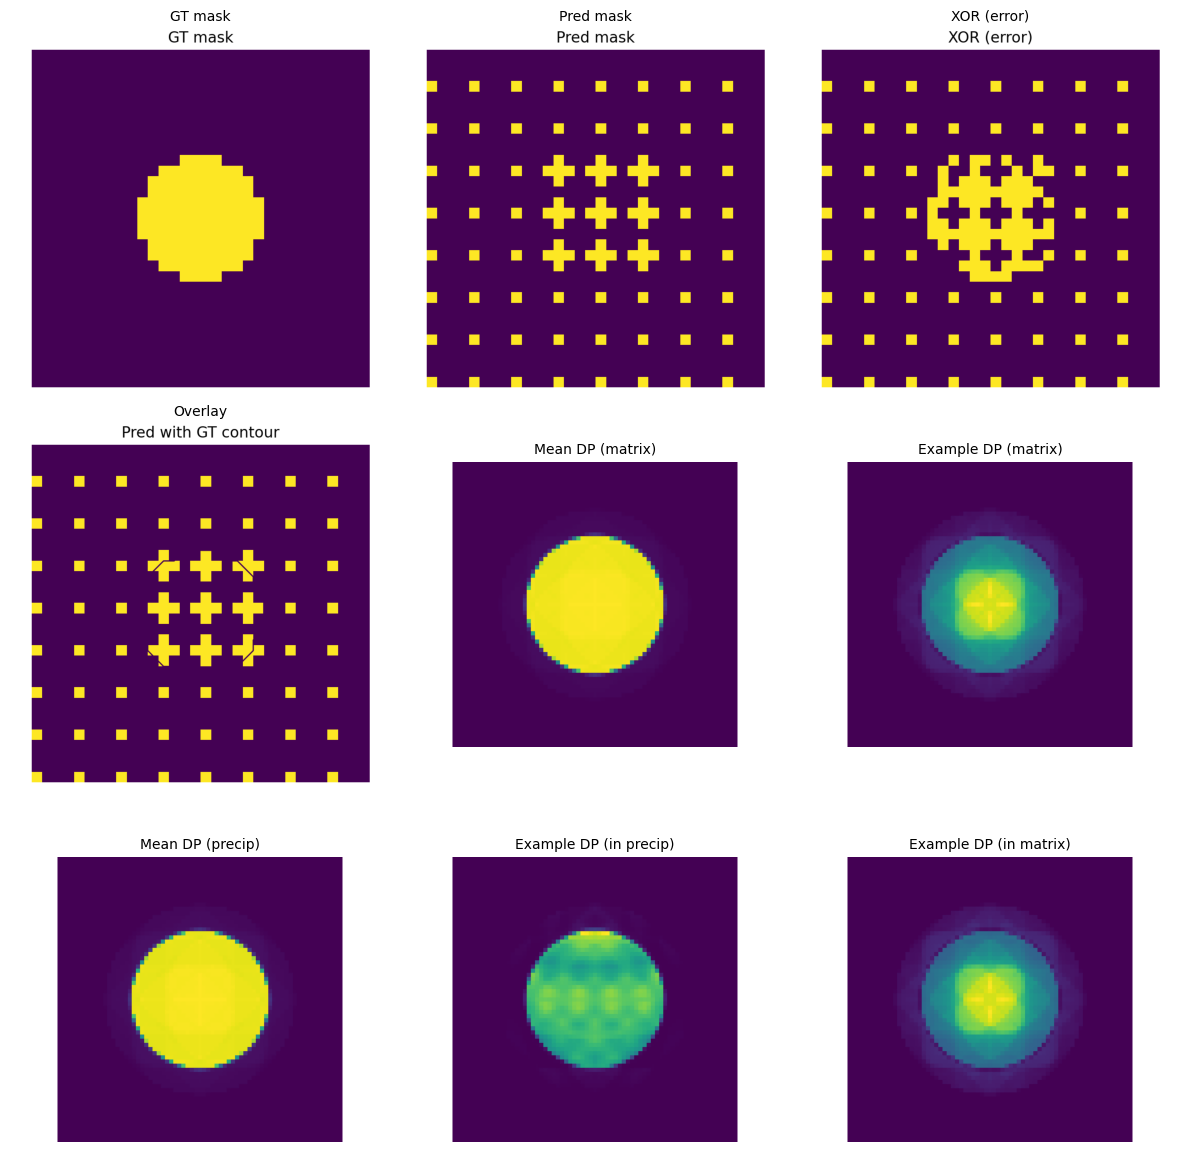

In [67]:
# Display all saved summary figures in a single grid (quick report sanity check).

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

OUTDIR = Path("abtem_outputs")

files = [
    ("GT mask", OUTDIR / "abtem_gt_mask.png"),
    ("Pred mask", OUTDIR / "abtem_pred_mask.png"),
    ("XOR (error)", OUTDIR / "abtem_xor.png"),
    ("Overlay", OUTDIR / "abtem_overlay.png"),
    ("Mean DP (matrix)", OUTDIR / "mean_dp_matrix.png"),
    ("Example DP (matrix)", OUTDIR / "example_dp_matrix.png"),
    ("Mean DP (precip)", OUTDIR / "mean_dp_precip.png"),
    ("Example DP (in precip)", OUTDIR / "example_dp_in_precip.png"),
    ("Example DP (in matrix)", OUTDIR / "example_dp_in_matrix.png"),
]

# Arrange images into a readable grid.
n = len(files)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.ravel()

for ax, (title, path) in zip(axes, files):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

# Hide unused subplot slots.
for ax in axes[len(files):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Note:

AbTEM validation was performed by simulating a 4D-STEM scan for an fcc Ni matrix containing a cylindrical W-rich region (ground-truth precipitate mask generated from the known cylinder geometry). The simulated dataset was exported in the same format required by our pipeline, (Ny, Nx, Ky, Kx), enabling direct reuse of the existing unsupervised detection workflow without modifications. Using GMM clustering with the full physics-motivated feature set (feature_set="all", radial_bins=40), the best cluster-to-precipitate assignment achieved IoU = 0.218 and F1 = 0.358 (precision = 0.380, recall = 0.339; TP = 38, FP = 62, FN = 74) against the ground-truth mask.

For the matrix-only abTEM simulation, forcing two clusters produced an approximately 50/50 split, which is expected for unsupervised clustering when n_clusters=2 is imposed in the absence of a true second phase. Accordingly, the matrix-only case is treated as a negative control demonstrating that clustering can partition nuisance variance even without precipitates, motivating a “no-precipitate” decision rule (e.g., model selection for 1 vs 2 clusters or separation-thresholding) when ground truth is unavailable.

### Main issue with the abTEM result (why the mask looks like a grid)

The main problem is that the unsupervised segmentation is dominated by **probe-position periodicity (electron channeling / unit-cell sublattice contrast)** rather than the precipitate boundary. In a perfect periodic crystal, the diffraction pattern can change systematically as the probe moves within the unit cell (e.g., “on-column” vs “off-column” positions). When we force `n_clusters=2`, the clustering often separates these periodic scan-position differences, producing a **checkerboard/grid-like label map** instead of a contiguous precipitate region.

This behavior is very plausibly amplified because our simulated structure is **too idealized** (perfect lattice with no thermal vibrations, defects, thickness/strain gradients, scan drift, detector nonuniformity, or significant noise). These real experimental effects typically reduce unit-cell channeling contrast and make phase-scale differences more dominant. abTEM can incorporate more realism by adding, for example, **thermal disorder** (e.g., small random atomic displacements via `atoms.rattle(...)`) and **shot noise** (Poisson noise on detector intensities), and potentially thickness/strain variation, which can help shift the strongest variance away from unit-cell periodicity toward the precipitate/matrix contrast.

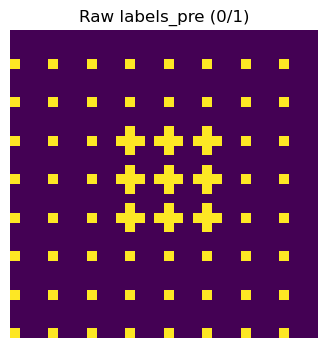

In [68]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.imshow(labels_pre, origin="lower")
plt.title("Raw labels_pre (0/1)")
plt.axis("off")
plt.show()

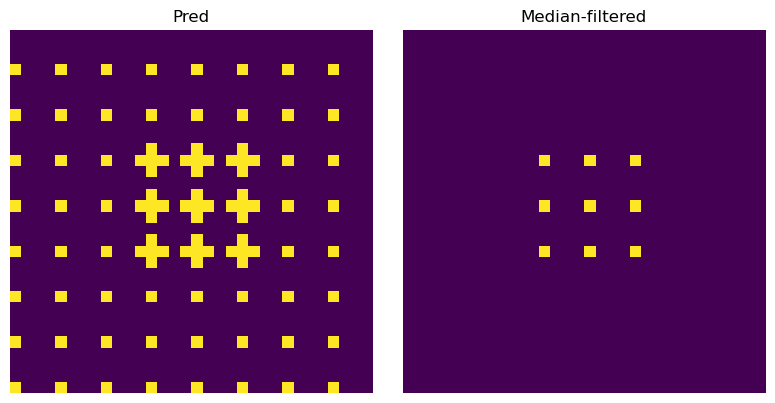

In [69]:
import numpy as np
import scipy.ndimage as ndi
import matplotlib.pyplot as plt

pred = (labels_pre == 1)  # or best label
pred_ref = ndi.median_filter(pred.astype(np.uint8), size=3).astype(bool)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(pred, origin="lower"); plt.title("Pred"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(pred_ref, origin="lower"); plt.title("Median-filtered"); plt.axis("off")
plt.tight_layout(); plt.show()

In [1]:
import json
import numpy as np
import fp_suppression as fps

OUTDIR = "abtem_outputs"

X_mat = np.load(f"{OUTDIR}/abtem_matrix.npy")
X_pre = np.load(f"{OUTDIR}/abtem_precip.npy")
gt    = np.load(f"{OUTDIR}/abtem_mask.npy").astype(bool)

cfg = fps.FPSuppressConfig(
    max_minor_frac=0.20,   # if clusters too balanced -> call "no precip"
    use_bic=True,
    bic_delta=0.0,
    precip_rule="smaller",
    median_size=0,
    min_component_size=0,
)

r_mat = fps.detect_fp_suppressed(X_mat, method="gmm", radial_bins=40, feature_set="all", cfg=cfg)
r_pre = fps.detect_fp_suppressed(X_pre, method="gmm", radial_bins=40, feature_set="all", cfg=cfg)

pred_mat = r_mat["pred_mask"].astype(bool)
pred_pre = r_pre["pred_mask"].astype(bool)

print("Matrix-only:", r_mat["k_selected"], r_mat["decision"], "pred frac:", pred_mat.mean())
print("Precip:",     r_pre["k_selected"], r_pre["decision"], "pred frac:", pred_pre.mean())

tp = np.logical_and(pred_pre, gt).sum()
fp_ = np.logical_and(pred_pre, ~gt).sum()
fn = np.logical_and(~pred_pre, gt).sum()
iou = tp / (tp + fp_ + fn + 1e-12)
f1  = 2*tp / (2*tp + fp_ + fn + 1e-12)
print("Precip IoU:", float(iou), "F1:", float(f1))

with open(f"{OUTDIR}/fp_suppression_diagnostics.json", "w") as f:
    json.dump({"matrix": r_mat["diagnostics"], "precip": r_pre["diagnostics"]}, f, indent=2)

print("saved:", f"{OUTDIR}/fp_suppression_diagnostics.json")

Matrix-only: 1 no-precip (balanced clusters, minor_frac=0.500) pred frac: 0.0
Precip: 2 k=2 pred frac: 0.09765625
Precip IoU: 0.2183908045976999 F1: 0.35849056603773416
saved: abtem_outputs/fp_suppression_diagnostics.json


In [2]:
import numpy as np

OUTDIR = "abtem_outputs"
np.save(f"{OUTDIR}/abtem_matrix_pred_mask_fp_suppressed.npy", pred_mat.astype(np.uint8))
print("saved:", f"{OUTDIR}/abtem_matrix_pred_mask_fp_suppressed.npy")

saved: abtem_outputs/abtem_matrix_pred_mask_fp_suppressed.npy


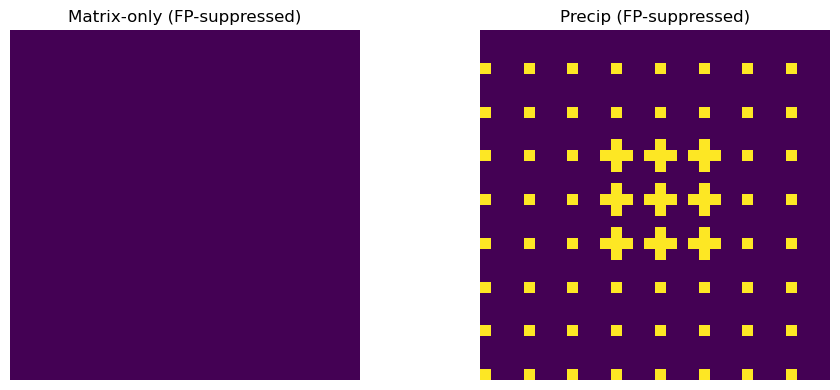

saved FP-suppressed masks to abtem_outputs


In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(pred_mat, origin="lower"); plt.title("Matrix-only (FP-suppressed)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(pred_pre, origin="lower"); plt.title("Precip (FP-suppressed)"); plt.axis("off")
plt.tight_layout(); plt.show()

np.save(f"{OUTDIR}/abtem_matrix_pred_mask_fp_suppressed.npy", pred_mat.astype(np.uint8))
np.save(f"{OUTDIR}/abtem_precip_pred_mask_fp_suppressed.npy", pred_pre.astype(np.uint8))
print("saved FP-suppressed masks to", OUTDIR)

In [4]:
import json
import numpy as np

OUTDIR = "abtem_outputs"
gt = np.load(f"{OUTDIR}/abtem_mask.npy").astype(bool)

def metrics(pred, gt):
    pred = pred.astype(bool); gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    tn = np.logical_and(~pred, ~gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2*tp / (2*tp + fp + fn + 1e-12)
    precision = tp / (tp + fp + 1e-12)
    recall    = tp / (tp + fn + 1e-12)
    return {
        "IoU": float(iou), "F1": float(f1),
        "precision": float(precision), "recall": float(recall),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
    }

fp_frac_matrix = float(pred_mat.mean())
met_pre = metrics(pred_pre, gt)

summary = {
    "FP_frac_matrix_only": fp_frac_matrix,
    "GT_precip_frac": float(gt.mean()),
    "pred_precip_frac": float(pred_pre.mean()),
    "metrics_precip": met_pre,
}

with open(f"{OUTDIR}/fp_suppression_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

print("FP_frac_matrix_only:", fp_frac_matrix)
print("Precip metrics:", met_pre)
print("saved:", f"{OUTDIR}/fp_suppression_metrics.json")

FP_frac_matrix_only: 0.0
Precip metrics: {'IoU': 0.2183908045976999, 'F1': 0.35849056603773416, 'precision': 0.37999999999999623, 'recall': 0.33928571428571125, 'TP': 38, 'FP': 62, 'FN': 74, 'TN': 850}
saved: abtem_outputs/fp_suppression_metrics.json


In [5]:
import numpy as np
import fp_suppression as fps

OUTDIR = "abtem_outputs"
X_mat = np.load(f"{OUTDIR}/abtem_matrix.npy")
X_pre = np.load(f"{OUTDIR}/abtem_precip.npy")
gt    = np.load(f"{OUTDIR}/abtem_mask.npy").astype(bool)

def iou_f1(pred, gt):
    pred = pred.astype(bool); gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2*tp / (2*tp + fp + fn + 1e-12)
    return float(iou), float(f1)

thresholds = [0.15, 0.20, 0.30]
print("cols: max_minor_frac, k_mat, FP_frac_mat, k_pre, pred_frac_pre, IoU_pre, F1_pre")

for thr in thresholds:
    cfg = fps.FPSuppressConfig(
        max_minor_frac=thr,
        use_bic=True,
        bic_delta=0.0,
        precip_rule="smaller",
        median_size=0,
        min_component_size=0,
    )
    r_mat = fps.detect_fp_suppressed(X_mat, method="gmm", radial_bins=40, feature_set="all", cfg=cfg)
    r_pre = fps.detect_fp_suppressed(X_pre, method="gmm", radial_bins=40, feature_set="all", cfg=cfg)

    pm = r_mat["pred_mask"].astype(bool)
    pp = r_pre["pred_mask"].astype(bool)
    iou, f1 = iou_f1(pp, gt)

    print(f"{thr:.2f}",
          r_mat["k_selected"], f"{pm.mean():.4f}",
          r_pre["k_selected"], f"{pp.mean():.4f}",
          f"{iou:.4f}", f"{f1:.4f}")

cols: max_minor_frac, k_mat, FP_frac_mat, k_pre, pred_frac_pre, IoU_pre, F1_pre
0.15 1 0.0000 2 0.0977 0.2184 0.3585
0.20 1 0.0000 2 0.0977 0.2184 0.3585
0.30 1 0.0000 2 0.0977 0.2184 0.3585


In [6]:
import json
import numpy as np
import pipelinefinalproject as pf
import fp_suppression as fps

OUTDIR = "abtem_outputs"
X_mat = np.load(f"{OUTDIR}/abtem_matrix.npy")
X_pre = np.load(f"{OUTDIR}/abtem_precip.npy")
gt    = np.load(f"{OUTDIR}/abtem_mask.npy").astype(bool)
ny, nx = X_pre.shape[:2]

def metrics(pred, gt):
    pred = pred.astype(bool); gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2*tp / (2*tp + fp + fn + 1e-12)
    return float(iou), float(f1)

# --- BEFORE (plain pipeline, forced k=2) ---
res_mat = pf.detect_phases_multi(X_mat, n_clusters=2, method="gmm", radial_bins=40, feature_set="all", verbose=False)
res_pre = pf.detect_phases_multi(X_pre, n_clusters=2, method="gmm", radial_bins=40, feature_set="all", verbose=False)
lab_mat = res_mat["labels"].reshape(ny, nx)
lab_pre = res_pre["labels"].reshape(ny, nx)

# best mapping for precip IoU
iou1, f11 = metrics(lab_pre==1, gt)
iou0, f10 = metrics(lab_pre==0, gt)
best_lab = 1 if iou1 >= iou0 else 0
pred_pre_before = (lab_pre == best_lab)
pred_mat_before = (lab_mat == 1)  # pipeline’s heuristic label

# --- AFTER (FP suppression wrapper) ---
cfg = fps.FPSuppressConfig(max_minor_frac=0.20, use_bic=True, precip_rule="smaller")
r_mat = fps.detect_fp_suppressed(X_mat, method="gmm", radial_bins=40, feature_set="all", cfg=cfg)
r_pre = fps.detect_fp_suppressed(X_pre, method="gmm", radial_bins=40, feature_set="all", cfg=cfg)
pred_mat_after = r_mat["pred_mask"].astype(bool)
pred_pre_after = r_pre["pred_mask"].astype(bool)

# report
before = {
    "FP_frac_matrix": float(pred_mat_before.mean()),
    "precip_IoU_F1": metrics(pred_pre_before, gt),
}
after = {
    "FP_frac_matrix": float(pred_mat_after.mean()),
    "precip_IoU_F1": metrics(pred_pre_after, gt),
    "k_selected_matrix": r_mat["k_selected"],
    "k_selected_precip": r_pre["k_selected"],
}

print("BEFORE:", before)
print("AFTER :", after)

with open(f"{OUTDIR}/fp_before_after.json", "w") as f:
    json.dump({"before": before, "after": after}, f, indent=2)
print("saved:", f"{OUTDIR}/fp_before_after.json")

BEFORE: {'FP_frac_matrix': 0.5, 'precip_IoU_F1': (0.2183908045976999, 0.35849056603773416)}
AFTER : {'FP_frac_matrix': 0.0, 'precip_IoU_F1': (0.2183908045976999, 0.35849056603773416), 'k_selected_matrix': 1, 'k_selected_precip': 2}
saved: abtem_outputs/fp_before_after.json
